# Classical SVM Classifier

Binary classification on the Iris dataset using a Support Vector Machine (SVM) with RBF kernel.

This notebook is the classical baseline for the `quantum_kernel` experiment.  
Results are saved to `svm_results.json` for use in `comparison/comparison.ipynb`.

**Configuration variable:** `N_FEATURES` controls how many features are used (2 or 4).  
For the 4-feature version, results are saved to `svm_results_4f.json` automatically.

## Imports

In [2]:
import time
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## Configuration

In [3]:
N_FEATURES  = 2          # 2 or 4
TEST_SIZE   = 0.2        # fraction of data held out for testing
RANDOM_SEED = 42         # reproducibility

RESULTS_FILE = "svm_results.json" if N_FEATURES == 2 else "svm_results_4f.json"

print(f"Configuration: N_FEATURES={N_FEATURES}, TEST_SIZE={TEST_SIZE}")
print(f"Results will be saved to: {RESULTS_FILE}")

Configuration: N_FEATURES=2, TEST_SIZE=0.2
Results will be saved to: svm_results.json


## Dataset

We use the Iris dataset restricted to **2 classes** (Versicolor vs Virginica, classes 1 and 2).  
Class 0 (Setosa) is dropped because it is linearly separable and trivially easy.

Features used:
- `N_FEATURES = 2`: petal length, petal width (most discriminative pair)
- `N_FEATURES = 4`: all four features

All features are scaled to [0, 1] with `MinMaxScaler`. The quantum kernel notebook applies
the same scaling so that both models receive identical input.

In [4]:
iris = load_iris()

mask     = iris.target != 0
X_full   = iris.data[mask]
y_full   = iris.target[mask] - 1

if N_FEATURES == 2:
    X = X_full[:, 2:4]
    feature_names = ["petal length", "petal width"]
else:
    X = X_full
    feature_names = list(iris.feature_names)

scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_full, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_full
)

print(f"Total samples : {len(X_scaled)}")
print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")
print(f"Features used : {feature_names}")
print(f"Class balance (train): {np.bincount(y_train)}")

Total samples : 100
Train samples : 80
Test samples  : 20
Features used : ['petal length', 'petal width']
Class balance (train): [40 40]


## Classical Algorithm — SVM with RBF Kernel

A Support Vector Machine finds the hyperplane that maximizes the margin between classes.
The RBF kernel maps the input to an infinite-dimensional feature space, allowing non-linear
decision boundaries.

This is the direct classical counterpart to the Quantum Kernel SVM: both use the same SVM
framework, the only difference being how the kernel matrix is computed — classically via
the RBF formula, or via inner products in a quantum feature space.

In [5]:
def train_svm(X_train, y_train):
    """Train an SVM with RBF kernel. Returns the fitted model and elapsed training time."""
    model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_SEED)
    t0    = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    return model, elapsed


def evaluate_model(model, X_train, y_train, X_test, y_test):
    """Evaluate the model and return a metrics dict."""
    y_pred_test  = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    acc_test  = accuracy_score(y_test,  y_pred_test)
    acc_train = accuracy_score(y_train, y_pred_train)

    cv_scores = cross_val_score(model, X_scaled, y_full, cv=5, scoring="accuracy")

    return {
        "accuracy_test"  : float(acc_test),
        "accuracy_train" : float(acc_train),
        "cv_mean"        : float(cv_scores.mean()),
        "cv_std"         : float(cv_scores.std()),
        "cv_scores"      : cv_scores.tolist(),
        "y_pred_test"    : y_pred_test.tolist(),
        "y_test"         : y_test.tolist(),
    }

## Run

In [6]:
svm_model, train_time = train_svm(X_train, y_train)
metrics               = evaluate_model(svm_model, X_train, y_train, X_test, y_test)

print(f"Training time : {train_time:.4f} s")
print(f"Test accuracy : {metrics['accuracy_test']:.4f}")
print(f"Train accuracy: {metrics['accuracy_train']:.4f}")
print(f"CV accuracy   : {metrics['cv_mean']:.4f} ± {metrics['cv_std']:.4f}")
print()
print(classification_report(metrics['y_test'], metrics['y_pred_test'],
                             target_names=["Versicolor", "Virginica"]))

Training time : 0.0052 s
Test accuracy : 0.8500
Train accuracy: 0.9750
CV accuracy   : 0.9400 ± 0.0374

              precision    recall  f1-score   support

  Versicolor       0.82      0.90      0.86        10
   Virginica       0.89      0.80      0.84        10

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20



## Plots

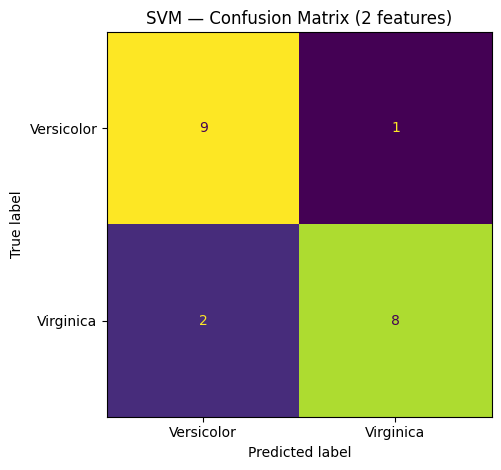

In [7]:
# --- Confusion matrix ---
cm   = confusion_matrix(metrics['y_test'], metrics['y_pred_test'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Versicolor", "Virginica"])
disp.plot(colorbar=False)
plt.title(f"SVM — Confusion Matrix ({N_FEATURES} features)")
plt.tight_layout()
plt.savefig(f"svm_confusion_matrix{'_4f' if N_FEATURES == 4 else ''}.png", dpi=150)
plt.show()

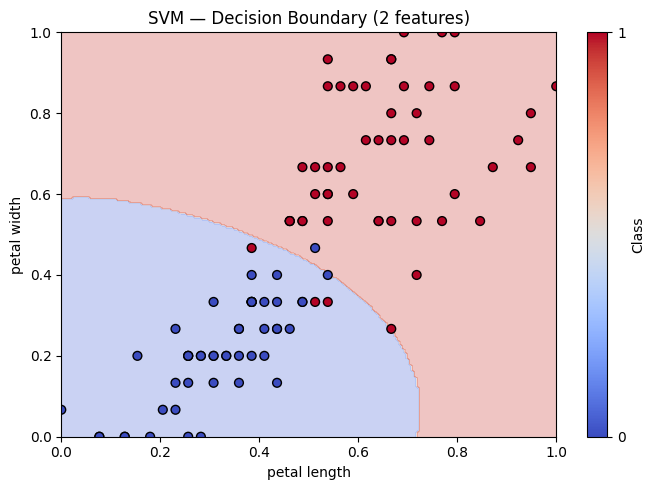

In [8]:
# --- Decision boundary (only for 2 features) ---
if N_FEATURES == 2:
    h = 0.005
    xx, yy = np.meshgrid(np.arange(0, 1 + h, h), np.arange(0, 1 + h, h))
    Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_full,
                          cmap="coolwarm", edgecolors="k", s=40)
    plt.colorbar(scatter, ticks=[0, 1], label="Class")
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title("SVM — Decision Boundary (2 features)")
    plt.tight_layout()
    plt.savefig("svm_decision_boundary.png", dpi=150)
    plt.show()
else:
    print("Decision boundary plot skipped (only available for N_FEATURES=2).")

## Save Results

In [9]:
results = {
    "model"             : "SVM-RBF",
    "n_features"        : N_FEATURES,
    "feature_names"     : feature_names,
    "n_train"           : int(len(X_train)),
    "n_test"            : int(len(X_test)),
    "random_seed"       : RANDOM_SEED,
    "train_time_s"      : float(train_time),
    "accuracy_test"     : metrics["accuracy_test"],
    "accuracy_train"    : metrics["accuracy_train"],
    "cv_mean"           : metrics["cv_mean"],
    "cv_std"            : metrics["cv_std"],
    "cv_scores"         : metrics["cv_scores"],
    "y_test"            : metrics["y_test"],
    "y_pred_test"       : metrics["y_pred_test"],
    "n_support_vectors" : int(sum(svm_model.n_support_)),
    "svm_C"             : svm_model.C,
    "svm_gamma"         : svm_model.gamma,
}

with open(RESULTS_FILE, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {RESULTS_FILE}")
print(json.dumps({k: v for k, v in results.items()
                  if k not in ("cv_scores", "y_test", "y_pred_test")}, indent=2))

Results saved to svm_results.json
{
  "model": "SVM-RBF",
  "n_features": 2,
  "feature_names": [
    "petal length",
    "petal width"
  ],
  "n_train": 80,
  "n_test": 20,
  "random_seed": 42,
  "train_time_s": 0.0052222449994587805,
  "accuracy_test": 0.85,
  "accuracy_train": 0.975,
  "cv_mean": 0.9399999999999998,
  "cv_std": 0.037416573867739396,
  "n_support_vectors": 17,
  "svm_C": 1.0,
  "svm_gamma": "scale"
}
